In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [78]:
file_id = "1eKOG9WAf3_6L0aVfi0dHstCLJqpmMdDN"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)


In [79]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [81]:
df.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [82]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [83]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [97]:
df.duplicated().sum()

np.int64(0)

In [84]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
object_column = df.select_dtypes(include = ['object']).columns

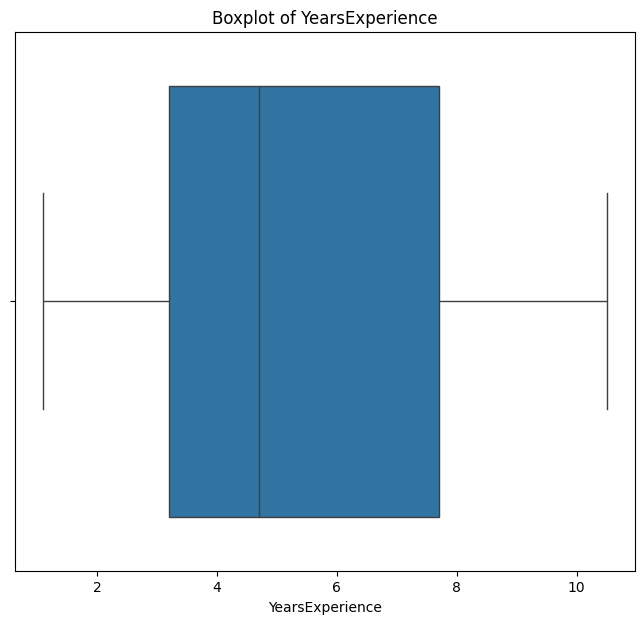

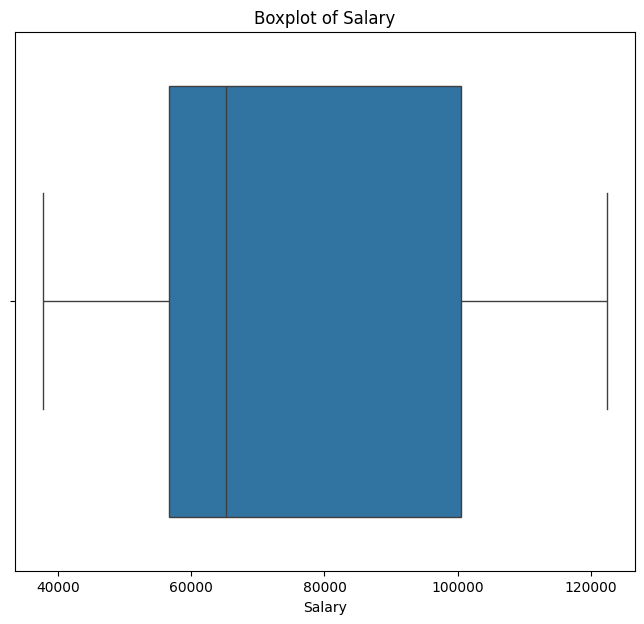

In [98]:
for i in numerical_columns:
  plt.figure(figsize = (8,7))
  sns.boxplot(x= df[i])
  plt.title(f"Boxplot of {i}")
  plt.show()

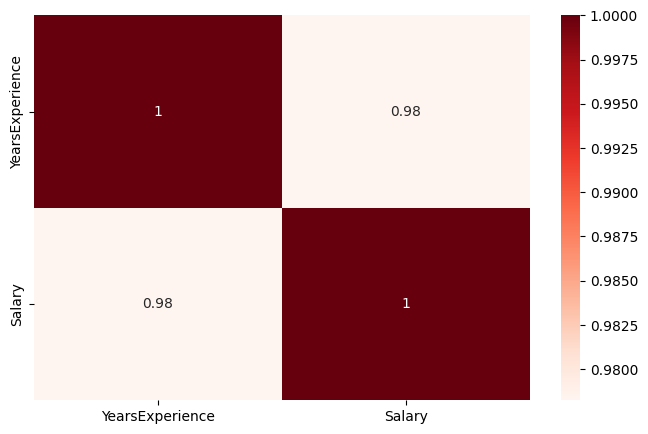

In [86]:
plt.figure(figsize = (8,5))
sns.heatmap(df.corr(numeric_only=True),annot = True, cmap = "Reds")
plt.show()

In [87]:
# divide Dependent Variables and Independent Variable s
x = df.drop('YearsExperience',axis = 1 )
y = df['YearsExperience']


In [88]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [89]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score


In [90]:
model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [91]:
y_pred = model.predict(x_test)

In [92]:
mae = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print("MAE:",mae)

print("r2:",r2)

print("RMSE:",mse)


MAE: 0.5191320118982409
r2: 0.9039484379486217
RMSE: 0.5191320118982409


In [93]:
result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

print(result)

    Actual  Predicted
27     9.6   9.120593
15     4.9   4.545795
23     8.2   9.241061
17     5.3   6.096418
8      3.2   4.188282
9      3.7   3.445621


In [94]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)
3

0.6522919548483541


3

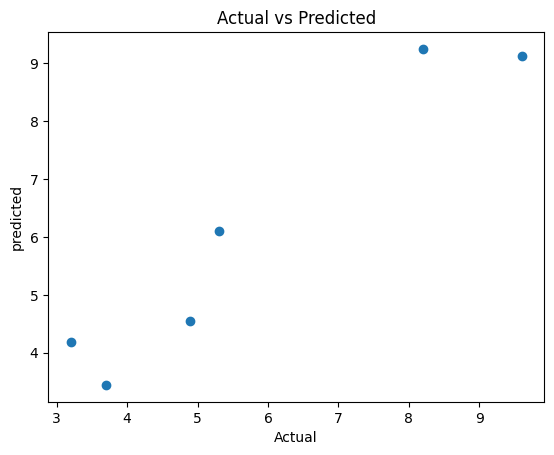

In [95]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('predicted')
plt.title('Actual vs Predicted')
plt.show()
